In [149]:
import pandas as pd
df = pd.read_csv("vendas_produtos_trimestres.csv")



dados = pd.read_csv("vendas_produtos_trimestres.csv")

dados

,produto_id,produto_nome,vendas_T1,vendas_T2,vendas_T3,vendas_T4,despesas_T1,despesas_T2,despesas_T3,despesas_T4
0,1,Produto A,14499,24847,18720,26298,17779,8576,8978,14173
1,2,Produto B,16672,15275,12837,23786,11650,14201,18199,13572
2,3,Produto C,19332,29591,19245,16148,9435,14055,14165,17485
3,4,Produto D,24457,19382,12464,26894,15352,9769,12313,18657
4,5,Produto E,18822,23977,26087,26793,19512,12423,9400,19583


In [150]:
dados_long = pd.wide_to_long(
    dados,
    stubnames=["vendas", "despesas"],
    i=["produto_id", "produto_nome"],
    j="trimestre",
    sep="_",
    suffix=r"\w+"
).reset_index   ()

display(dados_long)

,produto_id,produto_nome,trimestre,vendas,despesas
0,1,Produto A,T1,14499,17779
1,1,Produto A,T2,24847,8576
2,1,Produto A,T3,18720,8978
3,1,Produto A,T4,26298,14173
4,2,Produto B,T1,16672,11650
5,2,Produto B,T2,15275,14201
6,2,Produto B,T3,12837,18199
7,2,Produto B,T4,23786,13572
8,3,Produto C,T1,19332,9435
9,3,Produto C,T2,29591,14055


In [151]:
dados_long.columns

Index(['produto_id', 'produto_nome', 'trimestre', 'vendas', 'despesas'], dtype='str')

In [152]:
dados_long.index

RangeIndex(start=0, stop=20, step=1)

In [153]:
dados_long["lucro"]= dados_long["vendas"]- dados_long["despesas"]
dados_long

,produto_id,produto_nome,trimestre,vendas,despesas,lucro
0,1,Produto A,T1,14499,17779,-3280
1,1,Produto A,T2,24847,8576,16271
2,1,Produto A,T3,18720,8978,9742
3,1,Produto A,T4,26298,14173,12125
4,2,Produto B,T1,16672,11650,5022
5,2,Produto B,T2,15275,14201,1074
6,2,Produto B,T3,12837,18199,-5362
7,2,Produto B,T4,23786,13572,10214
8,3,Produto C,T1,19332,9435,9897
9,3,Produto C,T2,29591,14055,15536


In [154]:
dados_long.groupby("trimestre")[["vendas", "despesas", "lucro"]].sum()

,vendas,despesas,lucro
trimestre,,,
T1,93782,73728,20054
T2,113072,59024,54048
T3,89353,63055,26298
T4,119919,83470,36449


<Axes: xlabel='produto_nome'>

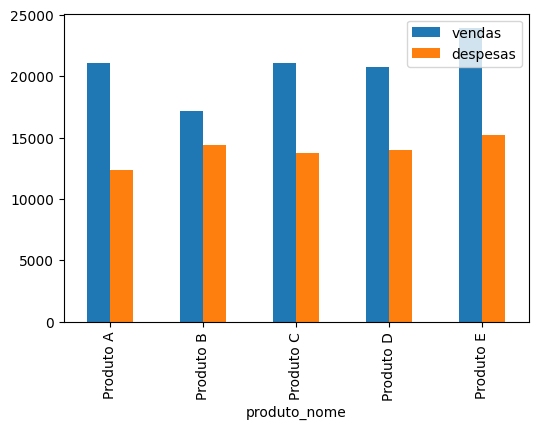

In [155]:
# kind é o tipo de gráfico 
# figsize é o tamanho da figura (largura, altura)
# plot desenhar o gráfico 

dados_long.groupby("produto_nome")[["vendas", "despesas"]].mean().plot(
    kind="bar",
    figsize=(6,4)
)

<Axes: xlabel='produto_nome'>

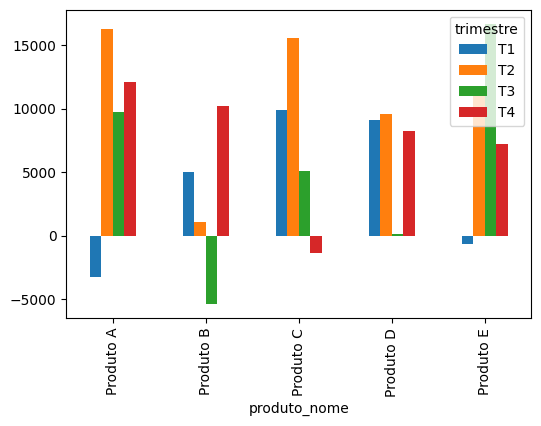

In [ ]:
dados_long.pivot_table(
    index="produto_nome", columns="trimestre", values="lucro",aggfunc="mean"
).plot(kind="bar", figsize=(6,4))   